In [32]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from pathlib import Path
from urllib.parse import urlparse
import requests



In [33]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["mathtext.rm"] = "Times New Roman"
mpl.rcParams["axes.unicode_minus"] = False
plt.style.use("tableau-colorblind10")

#mpl.style.use('tableau-colorblind10') 

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [34]:
EST_DIR = "to_comp_withWatanabe_paper"

EST_CO2_IMAGE  = os.path.join(EST_DIR, "CO2_RE_image.xlsx")
EST_CO2_REMIND = os.path.join(EST_DIR, "CO2_RE_remind.xlsx")

EST_CH4_IMAGE  = os.path.join(EST_DIR, "CH4_RE_image.xlsx")
EST_CH4_REMIND = os.path.join(EST_DIR, "CH4_RE_remind.xlsx")

EST_N2O_IMAGE  = os.path.join(EST_DIR, "N2O_RE_image.xlsx")
EST_N2O_REMIND = os.path.join(EST_DIR, "N2O_RE_remind.xlsx")

In [35]:
# -----------------------
# our inputs (our fair outputs)
# -----------------------
PKL_PATH  = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_1001ensemble_dicts.pkl"   
OURS_XLSX = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_2000_2500.xlsx"   


YEAR_MIN, YEAR_MAX = 2020, 2150

SCENARIOS = [
    ("ssp126", "SSP1-2.6", "2.6"),
    ("ssp245", "SSP2-4.5", "4.5"),
    ("ssp585", "SSP5-8.5", "8.5"),
]

SHEET_MAP = {"CO2": "CO2_RE", "CH4": "CH4_RE", "N2O": "N2O_RE"}
UNIT_FACTOR_TO_PPB = {"CO2": 1/1000.0, "CH4": 1.0, "N2O": 1.0}  # CO2 ppm^-1 -> ppb^-1

YLABEL_MAP = {
    "CO2": r"CO$_2$ (W m$^{-2}$ ppb$^{-1}$)",
    "CH4": r"CH$_4$ (W m$^{-2}$ ppb$^{-1}$)",
    "N2O": r"N$_2$O (W m$^{-2}$ ppb$^{-1}$)",
}


def read_est_excel_local(filepath: str) -> pd.DataFrame:
    """Read an EST Excel from local path, strip column names."""
    df = pd.read_excel(filepath)
    df.columns = df.columns.str.strip()
    return df

def find_scenario_col(df: pd.DataFrame | None, token: str) -> str | None:
    """Find first column containing token (e.g., '2.6', '4.5', '8.5')."""
    if df is None:
        return None
    cols = [c for c in df.columns if isinstance(c, str) and token in c]
    return cols[0] if cols else None

### now plot 

In [36]:
def plot_re_3x1_with_uncertainty_and_est(
    gas: str,
    pkl_path: str,
    ours_xlsx: str,
    est_image_path: str | None,
    est_remind_path: str | None,
    year_min: int = 2020,
    year_max: int = 2150,
    scenarios=SCENARIOS,
    band_q=(5, 95),
    band_alpha=0.20,
):
    gas = gas.upper()
    if gas not in SHEET_MAP:
        raise ValueError(f"gas must be one of {list(SHEET_MAP.keys())}")

    with open(pkl_path, "rb") as f:
        payload = pickle.load(f)

    ensemble_key_map = {
        "CO2": "co2_all_ensemble_dict",
        "CH4": "ch4_all_ensemble_dict",
        "N2O": "n2o_all_ensemble_dict",
    }
    ens_dict = payload[ensemble_key_map[gas]]["gas_re"]

    df_ours = pd.read_excel(ours_xlsx, sheet_name=SHEET_MAP[gas])
    df_ours.columns = df_ours.columns.str.strip()

    df_img = None
    df_rem = None
    if est_image_path:
        df_img = pd.read_excel(est_image_path)
        df_img.columns = df_img.columns.str.strip()
    if est_remind_path:
        df_rem = pd.read_excel(est_remind_path)
        df_rem.columns = df_rem.columns.str.strip()

    unit_factor = UNIT_FACTOR_TO_PPB[gas]
    qlo, qhi = band_q

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

    GAS_TITLE = {
        "CO2": r"CO$_2$",
        "CH4": r"CH$_4$",
        "N2O": r"N$_2$O",
    }

    for i, (ax, (ssp_key, scen_label, est_token)) in enumerate(zip(axes, scenarios)):
        years = df_ours["Year"].to_numpy(dtype=float)

        if ssp_key not in df_ours.columns:
            raise KeyError(f"'{ssp_key}' not found in '{SHEET_MAP[gas]}' sheet. Columns: {list(df_ours.columns)}")
        fair_med = df_ours[ssp_key].to_numpy(dtype=float) * unit_factor

        if ssp_key not in ens_dict:
            raise KeyError(f"'{ssp_key}' not found in ensemble dict for {gas}. Keys: {list(ens_dict.keys())}")
        ens = np.asarray(ens_dict[ssp_key], dtype=float) * unit_factor

        p_lo = np.percentile(ens, qlo, axis=1)
        p_hi = np.percentile(ens, qhi, axis=1)

        mask = (years >= year_min) & (years <= year_max)

        ax.fill_between(
            years[mask], p_lo[mask], p_hi[mask],
            alpha=band_alpha, color="lightblue",
            label=f"FaIR {qlo}–{qhi}%"
        )
        ax.plot(years[mask], fair_med[mask], label="FaIR median")

        img_col = _find_est_col(df_img, est_token)
        rem_col = _find_est_col(df_rem, est_token)

        if (df_img is not None) and (img_col is not None) and ("Year" in df_img.columns):
            est_img = pd.to_numeric(
                df_img.set_index("Year")[img_col].reindex(years), errors="coerce"
            ).to_numpy()
            ax.plot(years[mask], est_img[mask], label=f"Watanabe & Cherubini (2026); IMAGE")  #; {scen_label}

        if (df_rem is not None) and (rem_col is not None) and ("Year" in df_rem.columns):
            est_rem = pd.to_numeric(
                df_rem.set_index("Year")[rem_col].reindex(years), errors="coerce"
            ).to_numpy()
            ax.plot(years[mask], est_rem[mask],label = f"Watanabe & Cherubini (2026); REMIND") #; {scen_label}

        ax.set_title(f"{GAS_TITLE[gas]} radiative efficiency: {scen_label} ", fontsize=16) #({year_min}–{year_max})
        ax.set_ylabel(YLABEL_MAP[gas], fontsize=14)
        ax.grid(True)
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-5, -5))

        # ✅ Legend only on first subplot
        if i == 0:
            ax.legend(fontsize=14)

    axes[-1].set_xlabel("Year")
    fig.tight_layout()
    return fig

## CO2

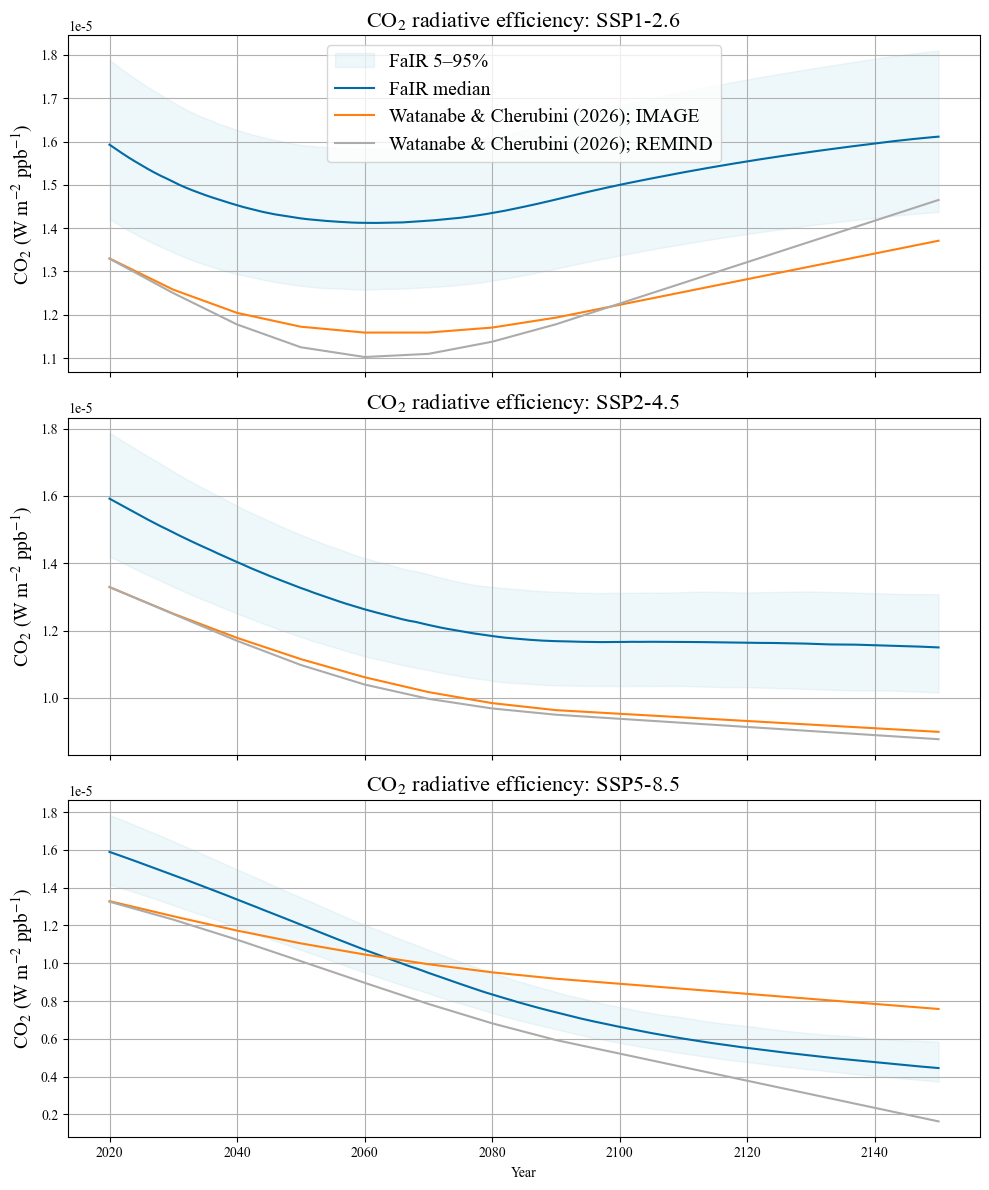

In [37]:
plot_re_3x1_with_uncertainty_and_est(
    gas="CO2",
    pkl_path=PKL_PATH,
    ours_xlsx=OURS_XLSX,
    est_image_path = "to_comp_withWatanabe_paper/CO2_RE_image.xlsx",  
    est_remind_path =   "to_comp_withWatanabe_paper/CO2_RE_remind.xlsx",  
    year_min=YEAR_MIN,
    year_max=YEAR_MAX,
)
plt.show()

## CH4

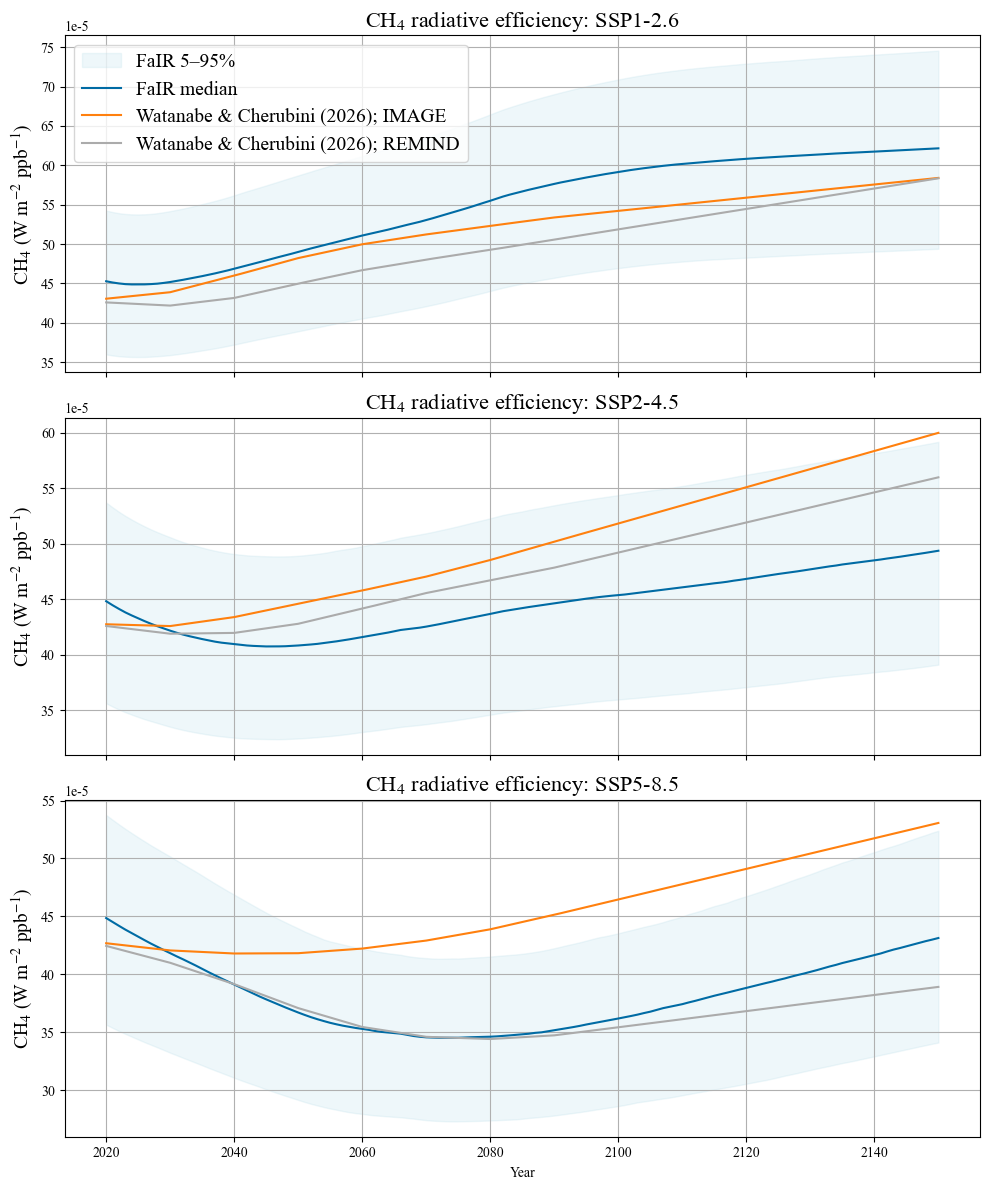

In [27]:
# CH4
plot_re_3x1_with_uncertainty_and_est(
    gas="CH4",
    pkl_path=PKL_PATH,
    ours_xlsx=OURS_XLSX,
    est_image_path = "to_comp_withWatanabe_paper/CH4_RE_image.xlsx",  
    est_remind_path =   "to_comp_withWatanabe_paper/CH4_RE_remind.xlsx",  
    year_min=YEAR_MIN,
    year_max=YEAR_MAX,
)
plt.show()

## N2O 

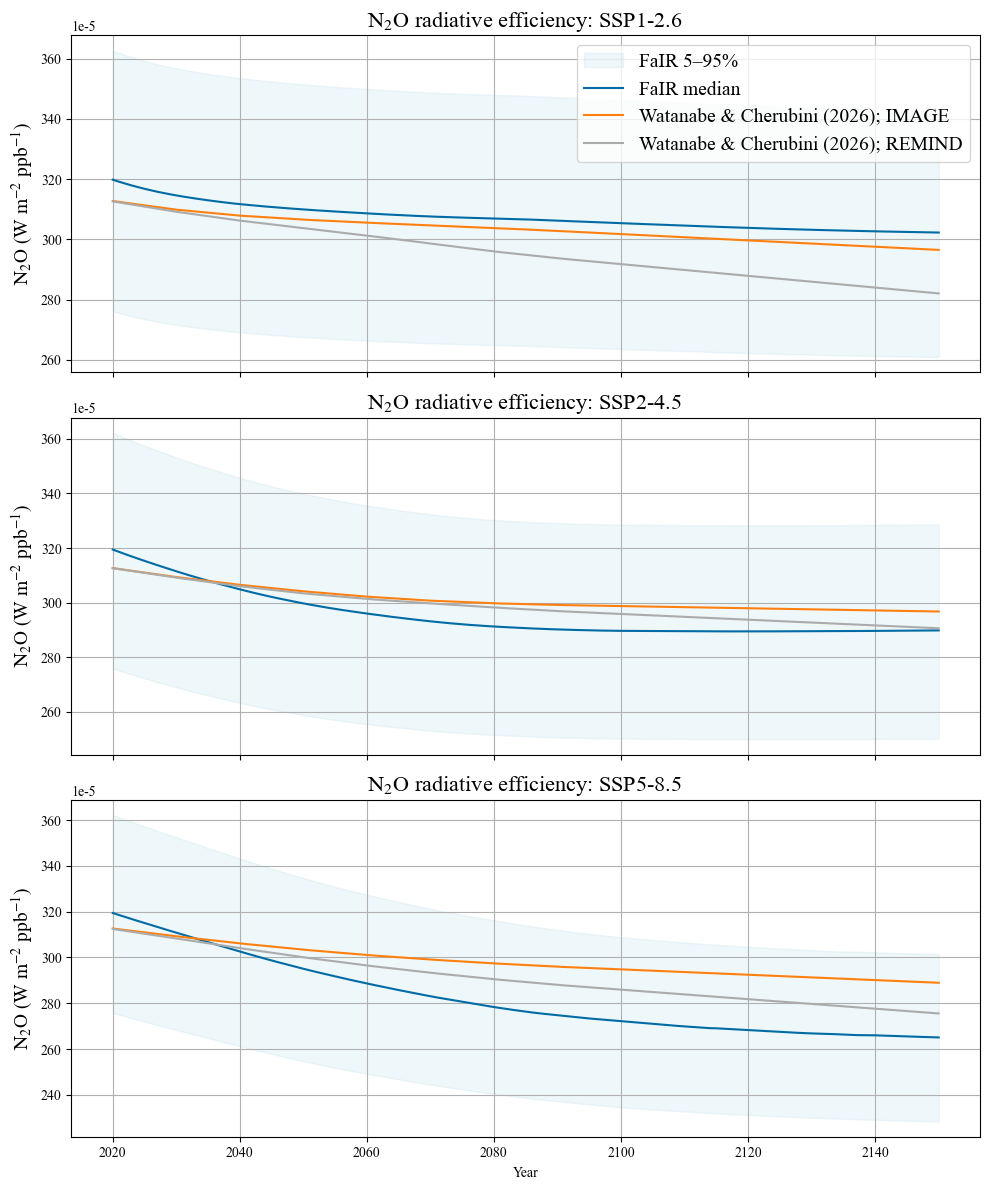

In [29]:
# N2O, there;s a naming issue in our FaIR worksheet for N2O, manually corrected 
plot_re_3x1_with_uncertainty_and_est(
    gas="N2O",
    pkl_path=PKL_PATH,
    ours_xlsx=OURS_XLSX,
    est_image_path = "to_comp_withWatanabe_paper/N2O_RE_image.xlsx",  
    est_remind_path = "to_comp_withWatanabe_paper/N2O_RE_remind.xlsx",  
    year_min=YEAR_MIN,
    year_max=YEAR_MAX,
)
plt.show()